# 11 — Optimization Algorithms: Momentum and Adaptive Methods

**Mathematical Foundations of Control and Machine Learning — Winter 2026**

> **Central question.** *What do memory and per-coordinate step sizes add to gradient descent, when do they help, and why is there no best optimizer?*

GD and SGD use only the current gradient, with one step size for all coordinates. This notebook organizes their refinements by two mechanisms — **memory** and **adaptivity** — rather than as a catalogue, connects momentum to the damped oscillator of control theory, and ends with comparisons that are fair by construction. The aim is to understand what each mechanism changes, not to rank methods.

### Table of Contents

1. **Two mechanisms: memory and adaptivity** — one map for all the methods
2. **MEMORY: the heavy-ball method** — and the conventions trap
3. **Momentum is a discretized damped oscillator** — critical damping picks the best $\beta$
4. **MEMORY on a whole spectrum** — Polyak's parameters and Nesterov's method
5. **ADAPTIVITY: per-coordinate step sizes** — AdaGrad and RMSProp, and what a diagonal rescaling cannot do
6. **Adam** — memory and adaptivity, with bias correction
7. **Four methods, three landscapes** — a quick qualitative tour with `torch.optim`
8. **A comparison that respects the protocol** — tuned on validation, tested once
9. **Control ↔ ML**
10. **Variance reduction** — control variates, SVRG, and the end of the noise floor
11. **Polyak's parameters, and a reference box**
12. **Do adaptive methods generalize worse?**
13. **Common misconceptions**
14. **Key takeaways**
15. **Exercises**

In [1]:
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import plotting as P           # the course palette, the house style, and the figure helpers

torch.manual_seed(0);

## Where are we?

> **Recap.** [Notebook 06](06_variational_principles_gradient_flows.ipynb): on a quadratic with condition number $\kappa$, gradient descent at its best step needs about $\frac\kappa2\ln(1/\delta)$ steps to gain a factor $\delta$, and its iterates zigzag across narrow valleys. [Notebook 05](05_feedback_stabilization.ipynb): for a damped oscillator, the decay rate is largest at critical damping; more damping makes the motion creep, less makes it oscillate. [Notebook 10](10_training_gd_sgd.ipynb): stochastic gradients, the cost unit, and the rule that every choice is made on validation data.

Three families of improvements over GD and SGD are classical: variance reduction, adaptive learning rates, and acceleration. This notebook organizes them by two mechanisms, **memory** and **adaptivity**, and puts variance reduction in §10. The aim is to understand what each mechanism changes, not to rank methods.

## 1. Two mechanisms: memory and adaptivity

Plain (stochastic) gradient descent is $w_k=w_{k-1}-\eta\,g_k$, with $g_k$ the (stochastic) gradient at $w_{k-1}$. The methods of this notebook modify it in two different ways, and we keep their recurrences separate rather than forcing them into one formula.

- **MEMORY** reuses past iterates: the step contains a fraction $\beta$ of the previous displacement. *Heavy ball*: $w_{k+1}=w_k-\eta\nabla f_i(w_k)+\beta(w_k-w_{k-1})$. *Nesterov*: the same, with the gradient evaluated at the look-ahead point $w_k+\beta(w_k-w_{k-1})$.
- **ADAPTIVITY** divides each coordinate of the gradient by its own scale, built from past squared gradients: $w^k_j=w^{k-1}_j-\eta_j^k\,g^k_j$, with $\eta_j^k=\eta/D_{k,j}$.

| Method | Direction | Per-coordinate divisor $D_k$ | $\varepsilon$ |
|---|---|---|---|
| AdaGrad | $g_k$ | $\sqrt{s_k+\varepsilon}$, $s_k=s_{k-1}+g_k^2$ | inside the root |
| RMSProp | $g_k$ | $\sqrt{s_k+\varepsilon}$, $s_k=\beta_2s_{k-1}+(1-\beta_2)g_k^2$ | inside the root |
| Adam | bias-corrected moving average $\hat m_k$ of the $g_\tau$ | $\sqrt{\hat s_k}+\varepsilon$, bias-corrected moving average of $g_\tau^2$ | outside the root |

Adam is the one method that combines both mechanisms: its direction has memory (a moving average), and its divisor is adaptive.

## 2. MEMORY: the heavy-ball method

**Observation.** SGD takes a lot of time in regions with a gentle slope, because the gradient there is small. **SGD with momentum** accumulates past steps in a velocity:
$$
v_{k+1}=\eta\,\nabla f_i(w_k)+\beta v_k,\qquad w_{k+1}=w_k-v_{k+1},\qquad v_0=0,
$$
or, equivalently, eliminating $v$,
$$
w_{k+1}=w_k-\eta\,\nabla f_i(w_k)+\beta\,(w_k-w_{k-1}),\qquad w_{-1}=w_0 .
\tag{HB}
$$
The term $\beta(w_k-w_{k-1})$ is the **momentum term**; $\beta=0$ gives back SGD, and $\beta$ is typically chosen slightly less than one, such as $0.9$. The picture is a heavy ball rolling down the hill instead of a man walking down it. With exact gradients this is Polyak's *heavy-ball method* (Polyak, 1964).

**Convention.** In this notebook (HB) is the canonical form. PyTorch's `torch.optim.SGD(momentum=beta)` instead accumulates the gradients *without* the step size:
$$
b_{k+1}=\beta b_k+\nabla f_i(w_k),\qquad w_{k+1}=w_k-\eta_k\,b_{k+1}.
$$
With $v_k=\eta b_k$, this is exactly (HB) **when $\eta$ is constant**, with the same $\beta$. When the learning rate changes during training, the two conventions produce different iterates: a change of $\eta_k$ rescales the whole accumulated velocity in the second form, but only the new gradient in the first. A value of $\beta$ can therefore be transferred between the two conventions only for constant steps.

## 3. Momentum is a discretized damped oscillator

The heavy ball has a precise continuous model: the damped second-order equation
$$
w''+\nu\,w'+\nabla F(w)=0,
$$
a particle in the potential $F$ with friction coefficient $\nu>0$. For $F(w)=\frac12w^2$ it is the damped oscillator $x''+kx'+x=0$ of [notebook 05](05_feedback_stabilization.ipynb), with $\nu=k$.

**The discretization identity.** Replace $w''$ by the centred difference and $w'$ by the backward difference, with time step $h$:
$$
\frac{w_{k+1}-2w_k+w_{k-1}}{h^2}+\nu\,\frac{w_k-w_{k-1}}h+\nabla F(w_k)=0 .
$$
Solving for $w_{k+1}$ gives exactly (HB) with
$$
\eta=h^2,\qquad\beta=1-\nu h .
$$
So $\beta$ close to $1$ means *little* friction, and $\beta=0$, plain GD, is the scheme with the *largest* friction $\nu=1/h$. This is an algebraic identity for this choice of differences; other discretizations give other conventions, and the dictionary changes with them.

**One quadratic mode.** Let $F(w)=\frac12\lambda w^2$, the behaviour of (HB) along one eigenvector of a quadratic. Then $w_{k+1}=(1+\beta-\eta\lambda)w_k-\beta w_{k-1}$, a linear recursion with characteristic equation
$$
z^2-(1+\beta-\eta\lambda)\,z+\beta=0 .
$$
Its convergence factor per step is $\rho(\beta)=\max|z|$.

> **Proposition 1 (heavy ball on one mode).**
> *Assumptions:* $\lambda>0$, $0<\eta\lambda<1$, $0\le\beta<1$.
>
> *Conclusion:* with $\beta_c=(1-\sqrt{\eta\lambda})^2$: for $\beta<\beta_c$ both roots are real and $\rho(\beta)>\sqrt{\beta}$ (*overdamped*); for $\beta\ge\beta_c$ the roots are complex or double and $\rho(\beta)=\sqrt\beta$ (*underdamped or critical*). $\rho$ is smallest at $\beta=\beta_c$, where $\rho=1-\sqrt{\eta\lambda}$, against $\rho(0)=1-\eta\lambda$ for GD.
>
> *Interpretation:* for this mode and this $\eta$, the asymptotic convergence factor is smallest at critical damping. Too little momentum creeps, too much oscillates, as for the damped oscillator of notebook 05; the factor improves from $1-\eta\lambda$ to $1-\sqrt{\eta\lambda}$. The factor is asymptotic: at $\beta_c$ the root is double, so the iterates behave like $(c_1+c_2k)\rho^k$, with a polynomial prefactor $k$.

*Proof.* The roots are complex iff $(1+\beta-\eta\lambda)^2<4\beta$, that is, iff $\big|1+\beta-\eta\lambda\big|<2\sqrt\beta$. Since $1+\beta-\eta\lambda>0$ here, this reads $(1-\sqrt\beta)^2<\eta\lambda$, i.e. $\sqrt\beta>1-\sqrt{\eta\lambda}$, i.e. $\beta>\beta_c$. Complex roots are conjugate with product $\beta$, so $|z|=\sqrt\beta$. For $\beta<\beta_c$ the roots are real, positive, with product $\beta$, and distinct, so the larger one exceeds $\sqrt\beta$; as $\beta$ decreases from $\beta_c$ to $0$ the larger root increases from $\sqrt{\beta_c}$ to $1-\eta\lambda$. Hence the minimum of $\rho$ is at $\beta_c$, with value $\sqrt{\beta_c}=1-\sqrt{\eta\lambda}$. $\square$

The laboratory compares the decay rate per unit time of (HB), $-\ln\rho/h$ with $\eta=h^2$ and $\nu=(1-\beta)/h$, with the decay rate $-\max\operatorname{Re}r$ of the oscillator $x''+\nu x'+x=0$ that notebook 05 plotted against its damping coefficient.

h = 0.1: best friction 1.88 (critical value 2 - h = 1.90), best rate 1.042 per unit time
h = 0.3: best friction 1.68 (critical value 2 - h = 1.70), best rate 1.170 per unit time
oscillator: best damping 1.98, best rate 0.990


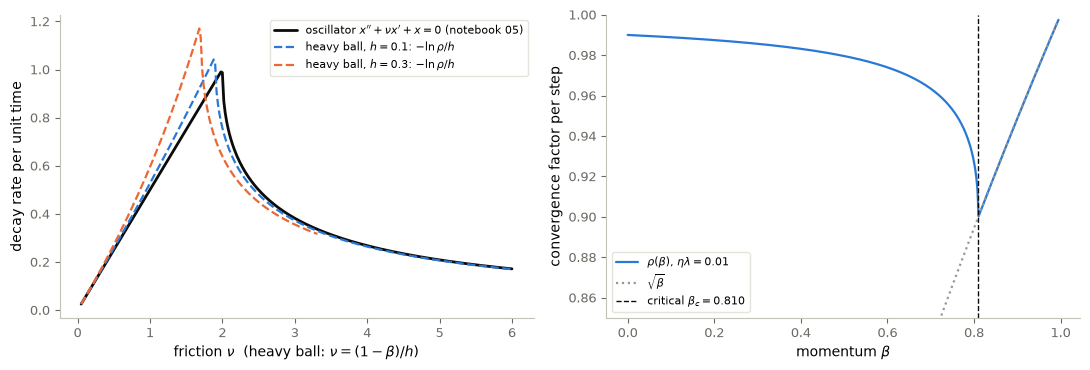

In [2]:
def hb_factor(eta, beta, lam):
    # spectral radius of the heavy-ball recursion on the mode F = lam w^2 / 2
    return np.abs(np.roots([1.0, -(1 + beta - eta * lam), beta])).max()

nus = np.linspace(0.05, 6.0, 300)                                           # damping / friction coefficient
rate_ode = np.array([-np.roots([1.0, nu, 1.0]).real.max() for nu in nus])   # oscillator x'' + nu x' + x = 0
rate_hb = {}
for h in (0.1, 0.3):                                                        # heavy ball with eta = h^2, beta = 1 - nu h
    valid = nus * h < 1
    rate_hb[h] = (nus[valid], np.array([-np.log(hb_factor(h**2, 1 - nu * h, 1.0)) / h for nu in nus[valid]]))
for h, (nu_h, r_h) in rate_hb.items():
    print(f"h = {h}: best friction {nu_h[np.argmax(r_h)]:.2f} (critical value 2 - h = {2 - h:.2f}), "
          f"best rate {r_h.max():.3f} per unit time")
print(f"oscillator: best damping {nus[np.argmax(rate_ode)]:.2f}, best rate {rate_ode.max():.3f}")

lam_mode, eta_mode = 1.0, 0.01                                              # one slow mode: eta * lambda = 0.01
betas = np.linspace(0, 0.995, 400)
factors = np.array([hb_factor(eta_mode, b, lam_mode) for b in betas])
beta_c = (1 - np.sqrt(eta_mode * lam_mode)) ** 2

fig, (ax1, ax2) = P.panels(2, figsize=(11.0, 3.8))
ax1.plot(nus, rate_ode, color=P.INK, lw=2, label=r"oscillator $x''+\nu x'+x=0$ (notebook 05)")
for (h, (nu_h, r_h)), color in zip(rate_hb.items(), (P.BLUE, P.ORANGE)):
    ax1.plot(nu_h, r_h, "--", color=color, label=rf"heavy ball, $h={h}$: $-\ln\rho/h$")
P.label(ax1, r"friction $\nu$  (heavy ball: $\nu=(1-\beta)/h$)", "decay rate per unit time")
ax2.plot(betas, factors, color=P.BLUE, label=r"$\rho(\beta)$, $\eta\lambda=0.01$")
ax2.plot(betas, np.sqrt(betas), ":", color=P.GREY, label=r"$\sqrt{\beta}$")
ax2.axvline(beta_c, color=P.INK, ls="--", lw=1, label=rf"critical $\beta_c={beta_c:.3f}$")
P.label(ax2, r"momentum $\beta$", "convergence factor per step", ylim=(0.85, 1.0))
plt.show()

**Figure 1.** Momentum as damping. *Left:* the decay rate of the oscillator $x''+\nu x'+x=0$ against the friction $\nu$ (notebook 05), and the decay rate per unit time of the heavy-ball method on $F(w)=\frac12w^2$, with $\eta=h^2$, $\beta=1-\nu h$, for two time steps $h$. *Right:* the convergence factor per step $\rho(\beta)$ of the heavy-ball method on one mode with $\eta\lambda=0.01$, the curve $\sqrt\beta$, and the critical momentum $\beta_c$.

*Interpretation.* On the left the discrete curves follow the continuous one, more closely for the smaller step: the heavy-ball method inherits the overdamping paradox of notebooks 01 and 05. Its best friction is the critical value $\nu=2-h$ (the printed grid values approximate it), close to the oscillator's $\nu=2$, and both smaller and larger friction slow it down. On the right, $\rho$ decreases while the mode is overdamped and then follows $\sqrt\beta$ once it is underdamped, with the minimum at $\beta_c$, as Proposition 1 states. There $\rho=0.9$, against $0.99$ for GD ($\beta=0$): ten times fewer steps for the same reduction. For one quadratic mode, momentum is a tuning of damping, and the asymptotically best damping is critical.

## 4. MEMORY on a whole spectrum: Polyak's parameters and Nesterov's method

A quadratic has many modes, with eigenvalues in $[\lambda_{\min},\lambda_{\max}]$, and one pair $(\eta,\beta)$ must serve all of them.

> **Proposition 2 (Polyak's heavy-ball parameters; derived in §11).**
> *Assumptions:* $F(w)=\frac12w^\top Qw-q^\top w$ with $Q$ symmetric, spectrum in $[\lambda_{\min},\lambda_{\max}]$, $\lambda_{\min}>0$, $\kappa=\lambda_{\max}/\lambda_{\min}$; the convention (HB) with exact gradients.
>
> *Conclusion:* the choice $\eta=\dfrac{4}{(\sqrt{\lambda_{\max}}+\sqrt{\lambda_{\min}})^2}$, $\beta=\Big(\dfrac{\sqrt\kappa-1}{\sqrt\kappa+1}\Big)^2$ minimizes the largest spectral radius of the iteration over the spectrum, and that radius is $\dfrac{\sqrt\kappa-1}{\sqrt\kappa+1}$.
>
> *Interpretation:* every mode is put in the critical or underdamped regime. The factor $\frac{\sqrt\kappa-1}{\sqrt\kappa+1}$ replaces GD's best $\frac{\kappa-1}{\kappa+1}$ (notebook 06): about $\sqrt\kappa$ instead of $\kappa$ steps per digit.

This is a statement about the *asymptotic* factor on quadratics. The iteration matrix is not symmetric, so transients can be larger than the factor suggests, and nothing here extends to nonconvex losses.

**Nesterov's method** evaluates the gradient at a look-ahead point:
$$
\tilde w_k=w_k+\beta(w_k-w_{k-1}),\qquad w_{k+1}=\tilde w_k-\eta\,\nabla f_i(\tilde w_k).
$$
It was invented by Nesterov in 1983 and popularized in machine learning by Sutskever et al. (2013); it differs from momentum only in *where* the gradient is evaluated. Its guarantees, *stated without proof and with exact gradients*, depend on the class of functions, and the two cases must not be mixed:

- **convex**, $L$-smooth $F$, with $\eta=1/L$ and the varying momentum $\beta_k=\frac{k-1}{k+2}$: $F(w_k)-F^*=O(1/k^2)$, against $O(1/k)$ for GD;
- **$\alpha$-strongly convex**, $L$-smooth $F$, with $\eta=1/L$ and the constant $\beta=\frac{\sqrt\kappa-1}{\sqrt\kappa+1}$, $\kappa=L/\alpha$: $F(w_k)-F^*\le C\,(1-1/\sqrt\kappa)^k$.

The laboratory runs the three memory methods on the quadratic landscape **E3** — eigenvalues $1$ and $\kappa=100$, valley rotated by $30^\circ$, as in notebook 06 — from the same start, with exact gradients.

> **Predict.** On E3 with $\kappa=100$, how many gradient evaluations do GD (best step), heavy ball (Polyak's parameters) and Nesterov (strongly convex parameters) need to gain $10^{-6}$?

Polyak: eta = 0.03306, beta = 0.6694, factor 0.8182;  GD best factor 0.9802
gradient evaluations to gain 1e-6 (one per iteration for all three): {'GD, best step': 691, 'heavy ball (Polyak)': 93, 'Nesterov (strongly convex)': 156}


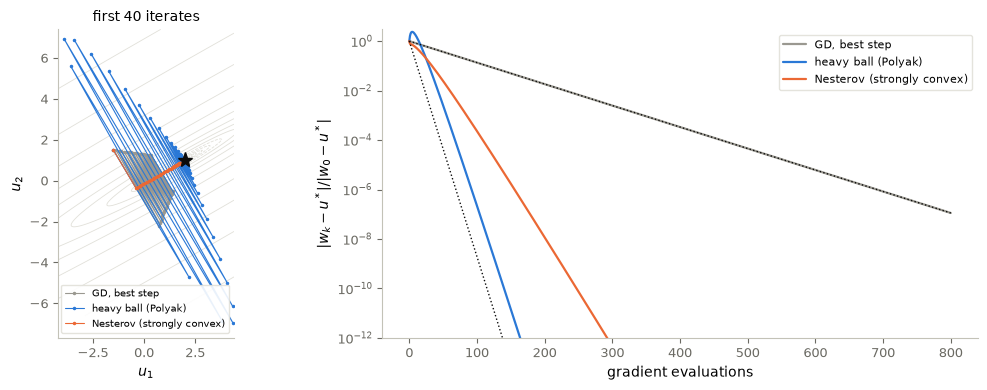

In [3]:
def gd(grad, w0, eta, n):
    ws = [np.asarray(w0, float)]
    for _ in range(n):
        ws.append(ws[-1] - eta * grad(ws[-1]))
    return np.array(ws)

def heavy_ball(grad, w0, eta, beta, n):
    ws = [np.asarray(w0, float)] * 2                       # w_{-1} = w_0
    for _ in range(n):
        ws.append(ws[-1] - eta * grad(ws[-1]) + beta * (ws[-1] - ws[-2]))
    return np.array(ws[1:])

def nesterov(grad, w0, eta, beta, n):
    ws = [np.asarray(w0, float)] * 2
    for _ in range(n):
        look = ws[-1] + beta * (ws[-1] - ws[-2])
        ws.append(look - eta * grad(look))
    return np.array(ws[1:])

def E3(kappa, angle=np.pi / 6):
    # E3: J(u) = 1/2 u^T Q u - q^T u, eigenvalues (1, kappa), valley rotated by `angle`; minimizer (2, 1)
    c, s = np.cos(angle), np.sin(angle)
    R = np.array([[c, -s], [s, c]])
    Q = R @ np.diag([1.0, kappa]) @ R.T
    return Q, Q @ np.array([2.0, 1.0])

kappa = 100.0
Q, q = E3(kappa)
u_star = np.linalg.solve(Q, q)
u0 = np.array([-1.5, 1.5])
lam_min, lam_max = np.linalg.eigvalsh(Q)
grad_E3 = lambda w: Q @ w - q
eta_hb = 4 / (np.sqrt(lam_max) + np.sqrt(lam_min)) ** 2                    # Polyak's parameters
beta_hb = ((np.sqrt(kappa) - 1) / (np.sqrt(kappa) + 1)) ** 2
rho_hb = (np.sqrt(kappa) - 1) / (np.sqrt(kappa) + 1)
n_iter = 800
memory_runs = {"GD, best step": gd(grad_E3, u0, 2 / (lam_min + lam_max), n_iter),
               "heavy ball (Polyak)": heavy_ball(grad_E3, u0, eta_hb, beta_hb, n_iter),
               "Nesterov (strongly convex)": nesterov(grad_E3, u0, 1 / lam_max, rho_hb, n_iter)}
memory_err = {name: np.linalg.norm(it - u_star, axis=1) / np.linalg.norm(u0 - u_star) for name, it in memory_runs.items()}
evals_to_1e6 = {name: (int(np.argmax(e <= 1e-6)) if np.any(e <= 1e-6) else None)   # None: not reached
                for name, e in memory_err.items()}
print(f"Polyak: eta = {eta_hb:.5f}, beta = {beta_hb:.4f}, factor {rho_hb:.4f};  GD best factor {(kappa - 1) / (kappa + 1):.4f}")
print("gradient evaluations to gain 1e-6 (one per iteration for all three):", evals_to_1e6)

fig, (ax1, ax2) = P.panels(2, figsize=(11.0, 4.0), ratios=[1, 1.25])
g1, g2 = np.meshgrid(np.linspace(-4.2, 4.4, 240), np.linspace(-6.6, 7.4, 240))
G = np.stack([g1, g2], -1)
vals = 0.5 * np.einsum("...i,ij,...j->...", G, Q, G) - G @ q
ax1.contour(g1, g2, vals, levels=np.geomspace(0.05, 4000, 16) + vals.min(), colors=P.GRID, linewidths=0.6)
for (name, it), color in zip(memory_runs.items(), (P.GREY, P.BLUE, P.ORANGE)):
    ax1.plot(*it[:40].T, ".-", ms=3, lw=0.8, color=color, label=name)
    ax2.semilogy(memory_err[name], color=color, label=name)
ax1.plot(*u_star, "*", color=P.INK, ms=11)
P.label(ax1, "$u_1$", "$u_2$", title="first 40 iterates", equal=True, legend={"fontsize": 7, "loc": "lower right"})
for rate in ((kappa - 1) / (kappa + 1), rho_hb):
    ax2.semilogy(np.arange(n_iter + 1), rate ** np.arange(n_iter + 1), ":", lw=1, color=P.INK)
P.label(ax2, "gradient evaluations", r"$|w_k-u^*|/|w_0-u^*|$", ylim=(1e-12, 3))
plt.show()

**Figure 2.** E3 with $\kappa=100$ from $u_0=(-1.5,1.5)$: GD at its best step, heavy ball with Polyak's parameters, Nesterov with $\eta=1/\lambda_{\max}$, $\beta=(\sqrt\kappa-1)/(\sqrt\kappa+1)$. *Left:* the first 40 iterates. *Right:* relative error against gradient evaluations (one per iteration), with the factors $\frac{\kappa-1}{\kappa+1}$ and $\frac{\sqrt\kappa-1}{\sqrt\kappa+1}$ dotted.

*Interpretation (answer to the prediction).* GD zigzags and needs several hundred evaluations, as in notebook 06; the memory methods travel along the valley and need an order of magnitude fewer (printed): the $\sqrt\kappa$ versus $\kappa$ of Proposition 2, up to constants and transients. The heavy-ball error first *grows* (the excursions on the left), then decreases with the Polyak factor: the iteration matrix is not symmetric, so a small asymptotic factor does not exclude transient growth. Same start, exact gradients, one gradient per iteration: the comparison is fair *for this quadratic*, and none of these factors is guaranteed with stochastic gradients or nonconvex losses.

## 5. ADAPTIVITY: per-coordinate step sizes

**The limitation.** GD uses the same learning rate for every coordinate. A step that is safe for a steep coordinate is tiny for a flat one, which is the origin of the factor $\kappa$. Why not $(w_{k+1})_j=(w_k)_j-\eta_{k,j}(\nabla f_i(w_k))_j$, with a step for each coordinate? The adaptive methods choose $\eta_{k,j}$ from the history of the $j$-th gradient component. With $g_k$ the (stochastic) gradient at $w_{k-1}$, and all operations coordinate-wise:

- **AdaGrad** (Duchi, Hazan and Singer, 2011): $s_k=s_{k-1}+g_k^2$, $s_0=0$, and $w_k=w_{k-1}-\dfrac{\eta}{\sqrt{s_k+\varepsilon}}\,g_k$. Large past gradients give small steps and vice versa, so all coordinates move at a comparable pace. The accumulated sum only grows, so the steps keep shrinking, which acts as a decreasing learning rate, and makes the method sensitive to the initial gradients.
- **RMSProp** (Hinton, 2012): replace the sum by a moving average, $s_k=\beta_2s_{k-1}+(1-\beta_2)g_k^2$, so that only recent gradients count (default $\beta_2=0.9$).

**What adaptivity can and cannot do.** Per-coordinate scaling is a *diagonal* rescaling of the problem. If the ill-conditioning is aligned with the coordinate axes, for instance $F(w)=\frac12(\lambda_1w_1^2+\lambda_2w_2^2)$, a diagonal rescaling removes it. If the narrow valley is oblique, no diagonal rescaling straightens it. The laboratory below runs the same methods on E3 with $\kappa=100$ in both positions: aligned with the axes, and rotated by $30^\circ$ as in notebook 06.

## 6. Adam: memory and adaptivity, with bias correction

**Adam** (Kingma and Ba, 2014) keeps exponentially decaying averages of the gradients and of their squares, for $k=1,2,\dots$:
$$
m_k=\beta_1m_{k-1}+(1-\beta_1)g_k,\qquad s_k=\beta_2s_{k-1}+(1-\beta_2)g_k^2,\qquad m_0=s_0=0,
$$
$$
\hat m_k=\frac{m_k}{1-\beta_1^k},\qquad\hat s_k=\frac{s_k}{1-\beta_2^k},\qquad w_k=w_{k-1}-\eta\,\frac{\hat m_k}{\sqrt{\hat s_k}+\varepsilon},
$$
with defaults $\eta=10^{-3}$, $\beta_1=0.9$, $\beta_2=0.999$, $\varepsilon=10^{-8}$. Note the convention: $\varepsilon$ is *outside* the square root for Adam and *inside* for AdaGrad and RMSProp; we keep both.

**Why the correction.** Unrolling the recursion with $m_0=0$,
$$
m_k=(1-\beta_1)\sum_{\tau=1}^k\beta_1^{\,k-\tau}g_\tau,\qquad\text{and}\qquad(1-\beta_1)\sum_{\tau=1}^k\beta_1^{\,k-\tau}=1-\beta_1^k .
$$
The weights of $m_k$ sum to $1-\beta_1^k$, not to $1$. If the $g_\tau$ have a common mean $\bar g$, then $\mathbb E\,m_k=(1-\beta_1^k)\bar g$: the estimate is **biased towards zero**, strongly in the first steps, since $1-\beta_1=0.1$ and $1-\beta_2=0.001$. Dividing by $1-\beta_1^k$ removes this bias exactly; the same computation applies to $s_k$ with $\beta_2$. Without the correction, the first step would be $\eta(1-\beta_1)/\sqrt{1-\beta_2}\approx3.2\,\eta$ in each coordinate instead of $\eta$ (Exercise 2). With it, the first step is $w_1=w_0-\eta\,g_1/(|g_1|+\varepsilon)\approx w_0-\eta\operatorname{sgn}(g_1)$, of size $\eta$ whatever the scale of the gradient.

**Scale invariance.** If $F$ is replaced by $cF$, $c>0$, all gradients are multiplied by $c$; $\hat m_k$ and $\sqrt{\hat s_k}$ are multiplied by $c$, and for $\varepsilon=0$ the iterates of Adam, RMSProp and AdaGrad do not change. GD's iterates do. The step of an adaptive method is set by $\eta$ in parameter units, not by the size of the gradient.

> **Predict.** On the aligned E3, will AdaGrad, RMSProp and Adam beat GD at its best step? On the rotated E3?

aligned with the axes: {'GD, best step': '1.4e-01', 'AdaGrad': '1.5e-03', 'RMSProp': '1.7e-02', 'Adam': '3.0e-03'} (relative error after 100 steps)
rotated by 30 degrees: {'GD, best step': '1.4e-01', 'AdaGrad': '4.8e-01', 'RMSProp': '6.2e-02', 'Adam': '5.1e-01'} (relative error after 100 steps)


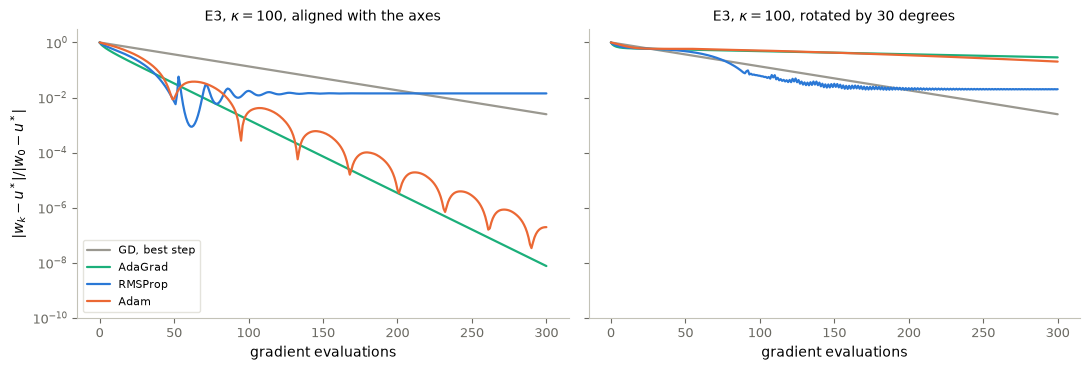

In [4]:
def adagrad(grad, w0, eta, n, eps=1e-8):
    w, s, ws = np.asarray(w0, float), np.zeros_like(w0), [np.asarray(w0, float)]
    for _ in range(n):
        g = grad(w); s = s + g * g
        w = w - eta / np.sqrt(s + eps) * g
        ws.append(w)
    return np.array(ws)

def rmsprop(grad, w0, eta, beta2, n, eps=1e-8):
    w, s, ws = np.asarray(w0, float), np.zeros_like(w0), [np.asarray(w0, float)]
    for _ in range(n):
        g = grad(w); s = beta2 * s + (1 - beta2) * g * g
        w = w - eta / np.sqrt(s + eps) * g
        ws.append(w)
    return np.array(ws)

def adam(grad, w0, eta, beta1, beta2, n, eps=1e-8):
    w, m, s, ws = np.asarray(w0, float), np.zeros_like(w0), np.zeros_like(w0), [np.asarray(w0, float)]
    for k in range(1, n + 1):
        g = grad(w)
        m, s = beta1 * m + (1 - beta1) * g, beta2 * s + (1 - beta2) * g * g
        w = w - eta * (m / (1 - beta1 ** k)) / (np.sqrt(s / (1 - beta2 ** k)) + eps)
        ws.append(w)
    return np.array(ws)

eta_adapt = {"AdaGrad": 0.5, "RMSProp": 0.1, "Adam": 0.1}                    # fixed in advance, not tuned
adapt_err = {}
for geometry, angle in (("aligned with the axes", 0.0), ("rotated by 30 degrees", np.pi / 6)):
    Qg, qg = E3(kappa, angle=angle)
    ug = np.linalg.solve(Qg, qg)
    grad_g = lambda w: Qg @ w - qg
    runs_g = {"GD, best step": gd(grad_g, u0, 2 / (1 + kappa), 300),
              "AdaGrad": adagrad(grad_g, u0, eta_adapt["AdaGrad"], 300),
              "RMSProp": rmsprop(grad_g, u0, eta_adapt["RMSProp"], 0.9, 300),
              "Adam": adam(grad_g, u0, eta_adapt["Adam"], 0.9, 0.999, 300)}
    adapt_err[geometry] = {name: np.linalg.norm(it - ug, axis=1) / np.linalg.norm(u0 - ug) for name, it in runs_g.items()}
    print(geometry + ":", {name: f"{e[100]:.1e}" for name, e in adapt_err[geometry].items()}, "(relative error after 100 steps)")

fig, axes = P.panels(2, figsize=(11.0, 3.8), sharey=True)
for ax, (geometry, errs) in zip(axes, adapt_err.items()):
    for (name, e), color in zip(errs.items(), (P.GREY, P.AQUA, P.BLUE, P.ORANGE)):
        ax.semilogy(np.maximum(e, 1e-17), color=color, label=name)
    P.label(ax, "gradient evaluations", title=f"E3, $\\kappa=100$, {geometry}", ylim=(1e-10, 3), legend=ax is axes[0])
axes[0].set_ylabel(r"$|w_k-u^*|/|w_0-u^*|$")
plt.show()

**Figure 3.** E3 with $\kappa=100$ and exact gradients, from $u_0=(-1.5,1.5)$: GD at its best step, AdaGrad ($\eta=0.5$), RMSProp ($\eta=0.1$, $\beta_2=0.9$) and Adam ($\eta=0.1$, default $\beta_1,\beta_2$). *Left:* the valley aligned with the coordinate axes. *Right:* the same valley rotated by $30^\circ$ (the E3 of notebook 06). The step sizes were fixed in advance, not tuned.

*Interpretation (answer to the prediction).* With the valley aligned, the adaptive methods leave GD far behind: per-coordinate scaling undoes the different curvatures of the two coordinates. With the valley rotated, the coordinates mix steep and flat directions, and no diagonal rescaling can separate them; in this experiment, with these step sizes and this budget, the advantage largely disappears (printed: the errors after 100 steps). The experiment does not show that adaptive methods never help on oblique valleys; it shows that their diagonal rescaling cannot by itself remove an oblique ill-conditioning. Memory (Figure 2) acts on the oblique valley directly.

## 7. Four methods, three landscapes

Before the formal comparison, a quick qualitative tour with `torch.optim` — the implementations actually used to train networks, with the PyTorch momentum convention of §2. The same four methods run on three landscapes of increasing realism, with step sizes fixed in advance: the quadratic E3 geometry ($\kappa=100$, 50 coordinates), the Rosenbrock valley (narrow, curved, nonconvex), and the training loss of a small `tanh` network on a one-dimensional regression task.

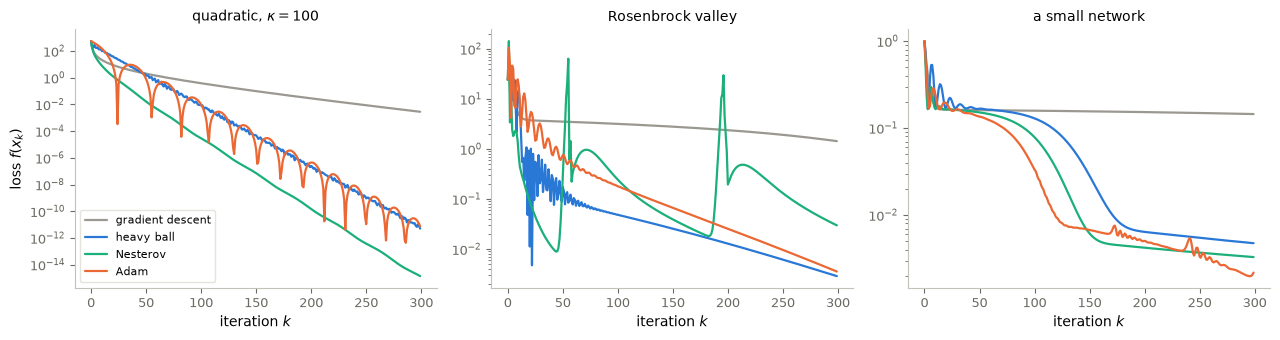

In [5]:
lam_spec = torch.logspace(0, 2, 50)                             # curvatures 1 ... 100, so kappa = 100
u_reg = torch.linspace(-1, 1, 64)[:, None]; v_reg = torch.sin(3 * u_reg) + 0.3 * u_reg

def quadratic():
    x = torch.ones(50, requires_grad=True)
    return [x], lambda: 0.5 * (lam_spec * x**2).sum()

def rosenbrock():
    x = torch.tensor([-1.2, 1.0], requires_grad=True)
    return [x], lambda: (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

def network():
    torch.manual_seed(0)
    net = nn.Sequential(nn.Linear(1, 32), nn.Tanh(), nn.Linear(32, 1))
    return list(net.parameters()), lambda: ((net(u_reg) - v_reg)**2).mean()

problems = {r"quadratic, $\kappa = 100$": (quadratic, 1 / 100, 0.05),     # (setup, step size, Adam step size)
            "Rosenbrock valley":          (rosenbrock, 2e-3, 0.5),
            "a small network":            (network, 5e-2, 0.03)}
methods = {"gradient descent": lambda p, eta, ad: torch.optim.SGD(p, eta),
           "heavy ball":       lambda p, eta, ad: torch.optim.SGD(p, eta, momentum=0.9),
           "Nesterov":         lambda p, eta, ad: torch.optim.SGD(p, eta, momentum=0.9, nesterov=True),
           "Adam":             lambda p, eta, ad: torch.optim.Adam(p, ad)}

def run(problem, method, n=300):
    setup, eta, ad = problems[problem]
    params, loss = setup()                                      # fresh start, identical for every method
    opt = methods[method](params, eta, ad)
    losses = []
    for _ in range(n):
        opt.zero_grad(); l = loss(); l.backward(); opt.step()
        losses.append(l.item())
    return losses

fig, axes = P.panels(3, size=(4.3, 3.5))
for ax, problem in zip(axes, problems):
    P.curves(ax, None, {method: (run(problem, method), col)
                        for method, col in zip(methods, [P.GREY, P.BLUE, P.AQUA, P.ORANGE])},
             log="y", xlabel="iteration $k$", title=problem, legend=ax is axes[0])
axes[0].set_ylabel("loss $f(x_k)$")
plt.show()

**Figure 4.** The same four `torch.optim` methods on three landscapes, loss per iteration (logarithmic scale), with step sizes fixed in advance per problem. Exact gradients; one gradient per iteration for all methods, so the iteration count is also the gradient-evaluation count.

*Interpretation.* On the quadratic, the picture of Figures 1–3 repeats: momentum accelerates along the slow modes, and Adam's per-coordinate scaling works because this quadratic is axis-aligned. On the curved Rosenbrock valley no method is uniformly ahead, and the ranking changes along the run. On the network loss — nonconvex, but mild — every method with memory or adaptivity clearly beats plain GD, and their mutual differences are small. Three landscapes, three different winners at various stages: a preview of §8's point that rankings only mean something under a declared protocol.

## 8. A comparison that respects the protocol

Comparisons of optimizers are easily unfair: one method gets a tuned step, another the default; or the test set decides. Here we compare mini-batch SGD, momentum ($\beta=0.9$) and Adam (default $\beta_1,\beta_2$) on a classification problem, under the rules of notebooks 09–10:

- **same task:** regularized logistic regression on E6 with all monomials of degree at most $3$ in the two coordinates (10 features, of very different sizes), $\lambda=10^{-3}$, the fixed split of notebook 09;
- **same start and budget:** $w=0$, mini-batches of $N_b=8$ samples drawn with replacement, 30 epochs, that is, the same number of per-sample gradient evaluations for every method;
- **choices on validation data only:** for each method the learning rate is chosen from the grid $\{0.01,0.03,0.1,0.3,1,3\}$ by the mean validation loss over 3 runs;
- **one test evaluation per method**, of the first run at the selected learning rate (decided in advance).

Cost: the tuning uses $6\times3\times30N=540N$ per-sample gradient evaluations per method; the selected model itself cost $30N$. Validation-loss evaluations are not counted as training gradients.

selected learning rates (validation): {'SGD': 3.0, 'momentum': 1.0, 'Adam': 0.3}
SGD       validation loss 0.039   test accuracy 1.000  (24 of 24 test points)
momentum  validation loss 0.037   test accuracy 1.000  (24 of 24 test points)
Adam      validation loss 0.038   test accuracy 1.000  (24 of 24 test points)


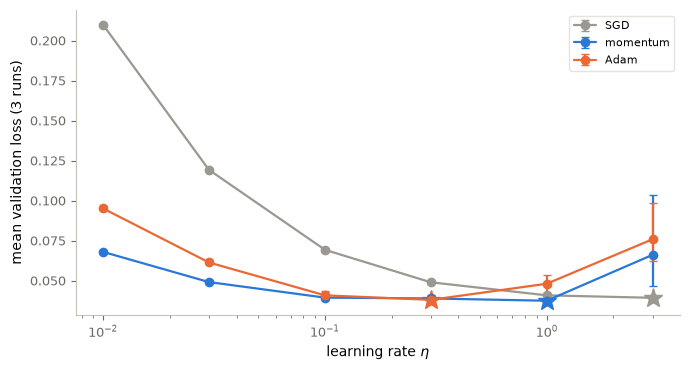

In [6]:
# E6: the two-class point cloud of notebooks 00, 09 and 10, with its fixed split
X6 = torch.cat([torch.randn(60, 2) * 0.45 + torch.tensor([-0.6, 0.0]),
                torch.randn(60, 2) * 0.45 + torch.tensor([1.3, 0.3])]).numpy()
y6 = np.repeat([0.0, 1.0], 60)
rng = np.random.default_rng(0)
idx6 = rng.permutation(len(y6))
train6, val6, test6 = idx6[:72], idx6[72:96], idx6[96:]

def monomials(X, degree=3):
    # all x1^a x2^b with a + b <= degree (the constant included)
    return np.column_stack([X[:, 0] ** a * X[:, 1] ** b for a in range(degree + 1) for b in range(degree + 1 - a)])

sig = lambda z: 1 / (1 + np.exp(-z))
def logistic_loss(w, A, y, lam):
    z = A @ w
    return np.mean(-y * z + np.logaddexp(0, z)) + lam / 2 * w @ w
accuracy = lambda w, A, y: np.mean((A @ w > 0) == y)

A_tr, A_val, A_test = (monomials(X6[s]) for s in (train6, val6, test6))
y_tr, y_val, y_test = y6[train6], y6[val6], y6[test6]
N6, lam6, B6 = len(y_tr), 1e-3, 8
n_steps6 = 30 * N6 // B6                                                    # 30 epochs: 30 N per-sample gradients
lr_grid = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0]

def stochastic_grad(w):                                                     # a fresh mini-batch at every call
    idx = rng.integers(0, N6, size=B6)
    z = A_tr[idx] @ w
    return ((sig(z) - y_tr[idx])[:, None] * A_tr[idx]).mean(axis=0) + lam6 * w

trainers = {"SGD": lambda eta: gd(stochastic_grad, np.zeros(10), eta, n_steps6)[-1],
            "momentum": lambda eta: heavy_ball(stochastic_grad, np.zeros(10), eta, 0.9, n_steps6)[-1],
            "Adam": lambda eta: adam(stochastic_grad, np.zeros(10), eta, 0.9, 0.999, n_steps6)[-1]}

val_loss, val_runs, first_run = {}, {}, {}
for method, train in trainers.items():
    losses = []
    for eta in lr_grid:
        ws = [train(eta) for _ in range(3)]
        first_run[(method, eta)] = ws[0]
        losses.append([logistic_loss(w, A_val, y_val, lam6) for w in ws])                   # VALIDATION only
    val_runs[method] = np.array(losses)                                                     # (6 rates, 3 runs)
    val_loss[method] = val_runs[method].mean(axis=1)
selected_lr = {method: lr_grid[int(np.argmin(v))] for method, v in val_loss.items()}
print("selected learning rates (validation):", selected_lr)

# One test evaluation per method, after all choices have been made.
test_accuracy = {method: accuracy(first_run[(method, eta)], A_test, y_test) for method, eta in selected_lr.items()}
for method in selected_lr:
    print(f"{method:9s} validation loss {min(val_loss[method]):.3f}   test accuracy {test_accuracy[method]:.3f}"
          f"  ({int(round(test_accuracy[method] * len(test6)))} of {len(test6)} test points)")

fig, ax = P.panels(figsize=(7.0, 3.8))
for (method, v), color in zip(val_loss.items(), (P.GREY, P.BLUE, P.ORANGE)):
    spread = np.vstack([v - val_runs[method].min(axis=1), val_runs[method].max(axis=1) - v])   # min-max of 3 runs
    ax.errorbar(lr_grid, v, yerr=spread, fmt="o-", capsize=3, color=color, label=method)
    ax.semilogx([selected_lr[method]], [min(v)], "*", ms=14, color=color)
ax.set_xscale("log")
P.label(ax, r"learning rate $\eta$", "mean validation loss (3 runs)")
plt.show()

**Figure 5.** Regularized logistic regression on E6, degree-3 monomial features: mean validation loss over 3 runs after 30 epochs ($N_b=8$), with min–max bars, against the learning rate, for SGD, momentum ($\beta=0.9$) and Adam. Stars mark the rates selected on validation. The test set appears nowhere in the figure; it is evaluated once per method after the selection (printed).

*Interpretation.* Each method has its own good range of learning rates; momentum's is shifted to smaller values, because its effective step is about $\eta/(1-\beta)=10\,\eta$, so a comparison at one common $\eta$ would be meaningless. After tuning on validation, the validation losses are close, and the single test evaluations coincide (printed). **These data do not allow a ranking**: the outcome depends on problem, budget, grid and seed. What the experiment shows is the procedure that makes such statements meaningful.

## 9. Control ↔ ML

- **Momentum and damping.** **MATHEMATICAL ANALOGY**, made exact by the discretization identity of §3: the heavy-ball method is a finite-difference scheme for $w''+\nu w'+\nabla F(w)=0$ with $\eta=h^2$, $\beta=1-\nu h$. On one quadratic mode the asymptotically best momentum is critical damping (Proposition 1), the overdamping paradox of notebooks 01 and 05 reappears as the choice of $\beta$, and Figure 1 shows the two decay-rate curves together. The analogy stops at the modelling level: in notebook 05 the damping acts on a physical system, here it is a parameter of an algorithm whose "potential" is a loss.
- **Gradient flows with inertia.** **DIRECT CONNECTION** to notebook 06: GD is explicit Euler for the first-order gradient flow, the heavy ball a scheme for the second-order flow with friction. Both have $F$ as a Lyapunov ingredient: for the continuous model, $\frac{d}{dt}\big(\tfrac12|w'|^2+F(w)\big)=-\nu|w'|^2\le0$.
- **Memory in the architecture.** **FORWARD CONNECTION.** Momentum can be put into network architectures themselves: *momentum neural ODEs*, $\ddot x=w(t)\sigma(a(t)\cdot x+b(t))$, with memory and the possibility that two points share the same position ([notebook 13](13_neuralodes.ipynb)).
- **Choosing hyperparameters.** **FORWARD CONNECTION.** Every trained model in notebooks [12](12_shallow_networks.ipynb)–16 reports its optimizer choices as validation choices, as in §8.

## 10. Variance reduction

Theorem 1 of notebook 10 needs decreasing steps because the variance of the stochastic gradient does not vanish at the minimizer. Variance reduction builds estimates whose variance *does* vanish there, so that constant steps work.

**Control variates.** To estimate $\mathbb EX$ with $X=\nabla f_I(w)$, take a variable $C$ correlated with $X$ whose mean is easy to compute, and set $Z_\alpha=\alpha(X-C)+\mathbb EC$, $\alpha\in[0,1]$. Then
$$
\mathbb EZ_\alpha=\alpha\,\mathbb EX+(1-\alpha)\,\mathbb EC,\qquad\mathbf VZ_\alpha=\alpha^2\big(\mathbf VX+\mathbf VC-2\,\mathbb C(X,C)\big),
$$
by linearity of the mean and bilinearity of the (co)variance. With $\alpha=1$ the estimate is unbiased, and its variance is small when $X$ and $C$ are strongly correlated.

**SVRG** (Johnson and Zhang, 2013) uses $C=\nabla f_I(\tilde w)$ at an old iterate $\tilde w$, whose mean is the full gradient $\nabla F(\tilde w)$, computed once per epoch:
$$
g=\nabla f_I(w)-\nabla f_I(\tilde w)+\nabla F(\tilde w).
$$
It is unbiased for every $\tilde w$, since the last two terms have mean zero together. If every $\nabla f_i$ is $L_{\max}$-Lipschitz (one constant for all $i$), then $|g-\nabla F(w)|\le|\nabla f_I(w)-\nabla f_I(\tilde w)|+|\nabla F(w)-\nabla F(\tilde w)|\le2L_{\max}|w-\tilde w|$, so the variance tends to zero when both $w$ and $\tilde w$ approach $w^*$: there is no noise floor. **SAG** (Schmidt, Le Roux and Bach, 2017) keeps in memory the last gradient of every $f_i$ and uses their average; **SAGA** (Defazio, Bach and Lacoste-Julien, 2014) uses $\nabla f_{i_k}(w)-g_{\rm old}(i_k)+\frac1N\sum_ig_{\rm old}(i)$, an unbiased variant. SAG and SAGA need memory for $N$ gradients; SVRG needs a full gradient per epoch.

**Convergence (qualitative).** With a **constant** step, these methods converge linearly on strongly convex problems. The analyses behind such statements assume in particular that every $f_i$ is convex with an $L_{\max}$-Lipschitz gradient, where $L_{\max}$ bounds the smoothness of *each* $f_i$ and can be much larger than the constant $L_F$ of the average $F$; that $F$ is strongly convex; and that the step is small and the epoch long enough relative to these constants. We do not reproduce those constants here. Without strong convexity, or for nonconvex losses, the statements change. Variance reduction is rarely used in deep learning: memory costs, and the suspicion that very precise optimization finds "bad" minima (notebook 10, §11).

The cell below compares SVRG with SGD on the strongly convex E6 logistic problem of notebook 10, by per-sample gradient evaluations (a full gradient costs $N$, an inner SVRG step $2$). The two smoothness constants differ (printed): $L_F$, from the Hessian of the average, and $L_{\max}=\max_i|\phi_i|^2/4+\lambda$, a common bound for the individual gradients. We use the constant step $\eta=0.1/L_{\max}$ and $m=2N$ inner steps. These parameters have not been checked against the constants of any theorem, so the run below is an observation about this problem.

L_F = 0.3319,  L_max = 1.3536


after 14400 per-sample gradient evaluations: SVRG gap 4.2e-14, SGD (Robbins-Monro) gap 3.0e-05
SVRG gap ratio per epoch, epochs 1-5: [0.12 0.3  0.38 0.42 0.44]  epochs 31-40: [0.5  0.5  0.51 0.51 0.53 0.54 0.55 0.56 0.58 0.6 ]


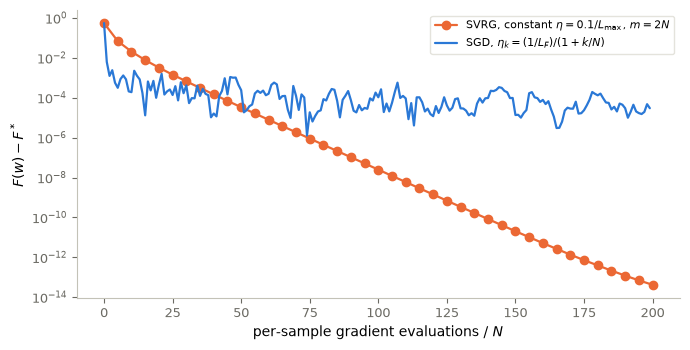

In [7]:
Phi_lin, y_lin = np.c_[X6, np.ones(len(y6))][train6], y6[train6]           # the problem of notebook 10
N_lin, lam_lin = len(y_lin), 1e-2
F_lin = lambda w: logistic_loss(w, Phi_lin, y_lin, lam_lin)
def grad_lin(w, idx):
    z = Phi_lin[idx] @ w
    return ((sig(z) - y_lin[idx])[:, None] * Phi_lin[idx]).mean(axis=0) + lam_lin * w
full_grad = lambda w: grad_lin(w, np.arange(N_lin))
L_F = np.linalg.eigvalsh(Phi_lin.T @ Phi_lin / N_lin)[-1] / 4 + lam_lin    # smoothness of the average F
L_max = np.max(np.sum(Phi_lin**2, axis=1)) / 4 + lam_lin                   # common bound for every f_i
print(f"L_F = {L_F:.4f},  L_max = {L_max:.4f}")
w_ref = np.zeros(3)                                                        # reference minimizer (Newton)
for _ in range(25):
    s = sig(Phi_lin @ w_ref)
    w_ref -= np.linalg.solve((Phi_lin * (s * (1 - s))[:, None]).T @ Phi_lin / N_lin + lam_lin * np.eye(3), full_grad(w_ref))
F_ref = F_lin(w_ref)

def svrg(w0, eta, n_epochs, m):
    w_tilde, snaps, evals = w0.copy(), [w0.copy()], [0]
    for _ in range(n_epochs):
        mu, w = full_grad(w_tilde), w_tilde.copy()
        for _ in range(m):
            i = rng.integers(N_lin)
            w = w - eta * (grad_lin(w, [i]) - grad_lin(w_tilde, [i]) + mu)
        w_tilde = w
        snaps.append(w.copy()); evals.append(evals[-1] + N_lin + 2 * m)
    return np.array(snaps), np.array(evals)

snaps, ev_svrg = svrg(np.zeros(3), 0.1 / L_max, 40, 2 * N_lin)
gap_svrg = np.array([F_lin(w) for w in snaps]) - F_ref
budget = int(ev_svrg[-1])                                                  # same gradient-evaluation budget for SGD
w_sgd, gap_sgd = np.zeros(3), []
for k in range(budget):
    if k % N_lin == 0:
        gap_sgd.append(F_lin(w_sgd) - F_ref)                               # once per equivalent data pass
    w_sgd = w_sgd - (1 / L_F) / (1 + k / N_lin) * grad_lin(w_sgd, [rng.integers(N_lin)])
gap_sgd = np.array(gap_sgd)
print(f"after {budget} per-sample gradient evaluations: SVRG gap {gap_svrg[-1]:.1e}, SGD (Robbins-Monro) gap {gap_sgd[-1]:.1e}")
print("SVRG gap ratio per epoch, epochs 1-5:", np.round(gap_svrg[1:6] / gap_svrg[:5], 2),
      " epochs 31-40:", np.round(gap_svrg[31:41] / gap_svrg[30:40], 2))

fig, ax = P.panels(figsize=(7.0, 3.6))
ax.semilogy(ev_svrg / N_lin, np.maximum(gap_svrg, 1e-16), "o-", color=P.ORANGE, label=r"SVRG, constant $\eta=0.1/L_{\max}$, $m=2N$")
ax.semilogy(np.arange(len(gap_sgd)), gap_sgd, color=P.BLUE, label=r"SGD, $\eta_k=(1/L_F)/(1+k/N)$")
P.label(ax, "per-sample gradient evaluations / $N$", r"$F(w)-F^*$")
plt.show()

**Figure 6.** The strongly convex E6 logistic problem of notebook 10: SVRG with a constant step $\eta=0.1/L_{\max}$ and epochs of $m=2N$ inner steps (gap at each snapshot), and SGD with the Robbins–Monro schedule of notebook 10, against per-sample gradient evaluations.

*Interpretation.* With a constant step, after a short transient the SVRG gap decreases by a nearly constant factor per epoch (printed ratios): a linear decrease, the qualitative behaviour predicted for strongly convex problems. It does not level off, while SGD with decreasing steps fluctuates and improves slowly. This is an observation for these parameters, which were not checked against a theorem's constants. Each SVRG epoch costs $N+2m=5N$ evaluations, so the comparison is made on the gradient-evaluation axis, not per epoch. The price is the full gradient at every snapshot, which is affordable for 72 samples and prohibitive for very large data sets or for deep networks.

## 11. Polyak's parameters, and a reference box

**Derivation of Proposition 2.** On the mode $\lambda$, the factor of (HB) is $\sqrt\beta$ if $(1-\sqrt\beta)^2\le\eta\lambda\le(1+\sqrt\beta)^2$ (complex or double roots, as in Proposition 1, extended to $1+\beta-\eta\lambda<0$ by symmetry), and larger outside that interval. To have the factor $\sqrt\beta$ on all of $[\lambda_{\min},\lambda_{\max}]$, the interval must contain $[\eta\lambda_{\min},\eta\lambda_{\max}]$:
$$
(1-\sqrt\beta)^2\le\eta\lambda_{\min},\qquad\eta\lambda_{\max}\le(1+\sqrt\beta)^2 .
$$
The smallest $\sqrt\beta$ for which some $\eta$ satisfies both is reached when both are equalities: dividing, $\frac{1+\sqrt\beta}{1-\sqrt\beta}=\sqrt\kappa$, so $\sqrt\beta=\frac{\sqrt\kappa-1}{\sqrt\kappa+1}$, and then $\eta=\frac{(1-\sqrt\beta)^2}{\lambda_{\min}}=\frac{4}{(\sqrt{\lambda_{\max}}+\sqrt{\lambda_{\min}})^2}$. A smaller $\sqrt\beta$ leaves some mode outside the interval, where the factor exceeds $\sqrt\beta$ and, at the extreme modes, exceeds $\frac{\sqrt\kappa-1}{\sqrt\kappa+1}$ (Exercise 3 checks this numerically).

**Reference box: AdaDelta and Adamax** (for completeness; not used in this course).

- *AdaDelta* (Zeiler, 2012): RMSProp with a step that adapts its own units, $w_{k+1}=w_k-\dfrac{\sqrt{r_{k-1}+\varepsilon}}{\sqrt{s_k+\varepsilon}}\,g_k$, where $s_k$ is the moving average of $g_k^2$ and $r_k$ the moving average of the squared updates; motivated by second-order methods.
- *Adamax* (Kingma and Ba, 2014): Adam with the second moment replaced by an exponentially weighted maximum, $u_k=\max(\beta_2u_{k-1},|g_k|)$, and the step $\eta\,\hat m_k/u_k$.

A classical animation in the literature shows several methods at a saddle point: methods that rescale coordinates leave the saddle quickly. Exercise 5 reproduces the mechanism on a short run, without ranking anything.

## 12. Do adaptive methods generalize worse?

The ingredients of popular deep-learning optimizers are *first order, stochastic, momentum, and different steps per coordinate* — and their generalization is poorly understood. Whether adaptive methods find solutions that generalize worse than those of well-tuned SGD with momentum is debated, with experiments pointing both ways (Wilson et al., 2017); the flat-versus-sharp-minima picture of notebook 10, §11, is one proposed explanation, and a disputed one. Two cautions follow from notebooks 09–11: such comparisons are only meaningful with the validation protocol of §8, and their conclusions are about particular problems, budgets and grids. The question returns when networks are trained as controlled dynamical systems in notebooks [13](13_neuralodes.ipynb) and 14.

## 13. Common misconceptions

**"Adam is the best optimizer."** No experiment here supports a universal ranking. Figure 3 shows adaptivity losing its advantage on an oblique valley (in that experiment), Figure 4 three landscapes with three different winners, Figure 5 no ranking after fair tuning, and Exercise 6 a problem where tuned momentum wins.

**"Larger momentum is always faster."** On one quadratic mode (Proposition 1), only up to critical damping; beyond it the asymptotic factor $\sqrt\beta$ grows and the iteration oscillates (Figure 1).

**"A value of $\beta$ means the same thing in every library."** It does for constant learning rates and the two conventions of §2; with schedules, or with other conventions, it must be converted.

**"Bias correction is a minor detail."** Without it the early steps of Adam are several times too large with the default parameters: about $3$ times at the first step, more than $6$ times around the tenth (§6, Exercise 2).

**"Nesterov's method converges like $1/k^2$."** For convex functions and exact gradients, with its varying momentum; for strongly convex functions the statement is a linear rate with other parameters; for stochastic or nonconvex problems neither is guaranteed (§4).

## 14. Key takeaways

1. Two mechanisms: *memory* (heavy ball, Nesterov) reuses past iterates; *adaptivity* (AdaGrad, RMSProp, Adam) divides each gradient coordinate by its own scale. Adam combines both.
2. Heavy ball: $w_{k+1}=w_k-\eta\nabla f(w_k)+\beta(w_k-w_{k-1})$. It discretizes $w''+\nu w'+\nabla F=0$ with $\eta=h^2$, $\beta=1-\nu h$.
3. On one quadratic mode the asymptotically best momentum is critical damping, $\beta_c=(1-\sqrt{\eta\lambda})^2$, with factor $1-\sqrt{\eta\lambda}$ instead of $1-\eta\lambda$.
4. On a quadratic with condition number $\kappa$, Polyak's parameters give the factor $\frac{\sqrt\kappa-1}{\sqrt\kappa+1}$: $\sqrt\kappa$ instead of $\kappa$ steps per digit.
5. Nesterov evaluates the gradient at a look-ahead point; its rates depend on convexity assumptions, which must be stated.
6. AdaGrad, RMSProp and Adam rescale coordinates; a diagonal rescaling removes ill-conditioning only when it is aligned with the coordinates.
7. Adam's bias correction divides by $1-\beta^k$, the total weight of the moving average.
8. Variance reduction (SVRG, SAG, SAGA) removes the noise floor on strongly convex finite sums, at a memory or full-gradient cost.
9. Optimizers are compared with the same objective, start and gradient budget, tuned on validation data, and tested once.

## 15. Exercises

★ conceptual · ★★ mathematical · ★★★ computational

1. **Momentum conventions. ★** (a) Show that the velocity form $v_{k+1}=\eta\nabla f(w_k)+\beta v_k$, $w_{k+1}=w_k-v_{k+1}$, $v_0=0$, gives (HB) with $w_{-1}=w_0$. (b) Show that the convention $b_{k+1}=\beta b_k+\nabla f(w_k)$, $w_{k+1}=w_k-\eta_kb_{k+1}$ coincides with (HB) when $\eta_k=\eta$ is constant. (c) If the learning rate is halved at step $K$, write the first step after $K$ in both conventions, and show that they differ.
2. **Adam without bias correction. ★★** (a) Assume all gradients equal a constant $g\ne0$ (one coordinate). Compute $m_k$ and $s_k$ in closed form, and show that $\hat m_k=g$ and $\hat s_k=g^2$ for every $k$. (b) Without correction, the step would be $\eta\,m_k/(\sqrt{s_k}+\varepsilon)$. With $\varepsilon=0$ and the defaults $\beta_1=0.9$, $\beta_2=0.999$, compute this step for $k=1,10,100,1000$, relative to $\eta$, and its limit. (c) Interpret the result.
3. **Heavy ball on a spectrum. ★★** (a) For E3 with $\kappa=100$, compute numerically the worst factor $\max_{\lambda\in[\lambda_{\min},\lambda_{\max}]}\rho(\eta,\beta,\lambda)$ of (HB) on a grid of $(\eta,\beta)$ around Polyak's parameters, and check that the minimum is at Polyak's values. (b) For fixed $\beta=\beta_{\rm Polyak}$, plot $\rho(\lambda)$ over the spectrum, and identify the critical modes. (c) Why is it not possible to make every mode critical at once?
4. **The SVRG estimator. ★★** Let $g=\nabla f_I(w)-\nabla f_I(\tilde w)+\nabla F(\tilde w)$ with $I$ uniform on $\{1,\dots,N\}$. (a) Show that $\mathbb Eg=\nabla F(w)$. (b) Show that $\mathbb E|g-\nabla F(w)|^2\le\frac1N\sum_i|\nabla f_i(w)-\nabla f_i(\tilde w)|^2$, and deduce the bound $L^2|w-\tilde w|^2$ when each $\nabla f_i$ is $L$-Lipschitz. (c) Compare with plain SGD at $w=\tilde w=w^*$.
5. **Leaving a saddle. ★★★** Take $F(w)=w_1^2-w_2^2$, which is unbounded below: no method "converges", so only the first steps are meaningful. Start at $w_0=(1,10^{-3})$ and run 40 steps of GD ($\eta=0.1$), heavy ball ($\eta=0.1$, $\beta=0.9$), RMSProp ($\eta=0.1$, $\beta_2=0.9$) and Adam ($\eta=0.1$). Plot $|w_{2,k}|$, the distance from the saddle's stable line, on a logarithmic scale. Explain the behaviour of the adaptive methods from the size of their first steps in the $w_2$ direction. Why would a ranking based on this experiment be meaningless?
6. **A problem where tuned momentum beats Adam. ★★★** On the rotated E3 with $\kappa=100$ and exact gradients, tune Adam's learning rate on the grid $\{0.003,0.01,0.03,0.1,0.3\}$ by the error after 300 steps (a training criterion: there is no data here), and compare with the heavy ball at Polyak's parameters. Explain the outcome with §§4–6. What does it say about default choices?
7. **Momentum off. ★** In the three-landscape laboratory of §7, set `momentum=0` in the heavy-ball method. Which method should it then reproduce, and do the curves agree?

In [8]:
# TODO: student exercise (Exercise 5)
# grad_saddle(w) = (2 w1, -2 w2). Run 40 steps of each method from w0 = (1, 1e-3) and plot |w_2| (log scale).

def grad_saddle(w):
    ...  # your code here
    return None

## Where are we going?

Part III has fixed what is learned and how it is judged (09), how a finite-sum loss is minimized with noisy gradients (10), and how memory and adaptivity change those methods (11). Part IV fuses control and learning: [notebook 12](12_shallow_networks.ipynb) studies shallow networks; notebooks [13](13_neuralodes.ipynb) and 14 read residual networks as controlled dynamical systems, trained with the methods of Part III — with the momentum of this notebook available inside the architecture itself.

## References

1. B. T. Polyak, [*Some methods of speeding up the convergence of iteration methods*](https://doi.org/10.1016/0041-5553(64)90137-5), USSR Computational Mathematics and Mathematical Physics **4** (1964), 1–17.
2. Y. E. Nesterov, [*A method for solving the convex programming problem with convergence rate $O(1/k^2)$*](https://www.mathnet.ru/eng/dan46009), Doklady Akademii Nauk SSSR **269** (1983), 543–547.
3. I. Sutskever, J. Martens, G. Dahl, G. Hinton, [*On the importance of initialization and momentum in deep learning*](https://proceedings.mlr.press/v28/sutskever13.html), ICML 2013.
4. J. Duchi, E. Hazan, Y. Singer, [*Adaptive subgradient methods for online learning and stochastic optimization*](https://jmlr.org/papers/v12/duchi11a.html), JMLR **12** (2011), 2121–2159.
5. G. Hinton, [*Neural Networks for Machine Learning, Lecture 6*](https://www.cs.toronto.edu/~hinton/coursera/lecture6/lec6.pdf), 2012 — RMSProp.
6. M. D. Zeiler, [*ADADELTA: an adaptive learning rate method*](https://arxiv.org/abs/1212.5701), arXiv:1212.5701, 2012.
7. D. P. Kingma, J. Ba, [*Adam: a method for stochastic optimization*](https://arxiv.org/abs/1412.6980), ICLR 2015.
8. R. Johnson, T. Zhang, [*Accelerating stochastic gradient descent using predictive variance reduction*](https://papers.nips.cc/paper/2013/hash/ac1dd209cbcc5e5d1c6e28598e8cbbe8-Abstract.html), NeurIPS 2013 — SVRG.
9. M. Schmidt, N. Le Roux, F. Bach, [*Minimizing finite sums with the stochastic average gradient*](https://doi.org/10.1007/s10107-016-1030-6), Mathematical Programming **162** (2017), 83–112 — SAG.
10. A. Defazio, F. Bach, S. Lacoste-Julien, [*SAGA: a fast incremental gradient method*](https://papers.nips.cc/paper/2014/hash/ede7e2b6d13a41ddf9f4bdef84fdc737-Abstract.html), NeurIPS 2014.
11. A. C. Wilson, R. Roelofs, M. Stern, N. Srebro, B. Recht, [*The marginal value of adaptive gradient methods in machine learning*](https://arxiv.org/abs/1705.08292), NeurIPS 2017.